# 06 · Memory Footprint and Multi-GPU Training

**Goal:** estimate *before you run* whether a model fits in GPU memory, and understand how data parallelism splits the work.

Memory during training (per parameter, fp32 + Adam):

| item | bytes / param |
|---|---|
| weights | 4 |
| gradients | 4 |
| Adam $m$ and $v$ | 8 |
| **total** | **16** |

plus **activations**, which scale with batch size and are stored for backprop.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(3)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

## 1. A memory estimator

In [2]:
OPT_STATES = {"sgd": 0, "momentum": 1, "adam": 2}      # extra fp32 copies per parameter

def n_params(sizes):
    return sum(i * o + o for i, o in zip(sizes[:-1], sizes[1:]))

def activation_numbers(sizes, batch):
    """Stored for backprop: X, plus Z and A of every layer."""
    return batch * (sizes[0] + 2 * sum(sizes[1:]))

def training_memory(sizes, batch, optimizer="adam", bytes_per=4):
    P = n_params(sizes)
    return dict(weights=P * bytes_per,
                grads=P * bytes_per,
                optimizer=OPT_STATES[optimizer] * P * 4,
                activations=activation_numbers(sizes, batch) * bytes_per)

sizes = [784, 4096, 4096, 10]
m = training_memory(sizes, batch=256)
for k, v in m.items():
    print(f"{k:<12}{v/1e6:10.2f} MB")
print(f"{'TOTAL':<12}{sum(m.values())/1e6:10.2f} MB")

weights          80.15 MB
grads            80.15 MB
optimizer       160.30 MB
activations      17.60 MB
TOTAL           338.20 MB


### Verify the estimate against real arrays
We allocate float32 weights, gradients, Adam states and a forward cache and count their `nbytes`.

In [3]:
B = 256
W = [rng.normal(0, 0.02, (i, o)).astype(np.float32) for i, o in zip(sizes[:-1], sizes[1:])]
b = [np.zeros(o, np.float32) for o in sizes[1:]]
X = rng.normal(size=(B, sizes[0])).astype(np.float32)

# forward pass storing Z and A
A, store = X, [X]
for l in range(len(W)):
    Z = A @ W[l] + b[l]
    A = softmax(Z) if l == len(W) - 1 else np.maximum(0, Z)
    store += [Z, A]

real = dict(
    weights=sum(a.nbytes for a in W + b),
    grads=sum(a.nbytes for a in W + b),            # same shapes as the parameters
    optimizer=2 * sum(a.nbytes for a in W + b),    # Adam: m and v
    activations=sum(a.nbytes for a in store),
)
for k in m:
    print(f"{k:<12} estimate = {m[k]/1e6:9.2f} MB | measured = {real[k]/1e6:9.2f} MB")
assert all(m[k] == real[k] for k in m)

weights      estimate =     80.15 MB | measured =     80.15 MB
grads        estimate =     80.15 MB | measured =     80.15 MB
optimizer    estimate =    160.30 MB | measured =    160.30 MB
activations  estimate =     17.60 MB | measured =     17.60 MB


## 2. Activations grow with batch size, parameters do not

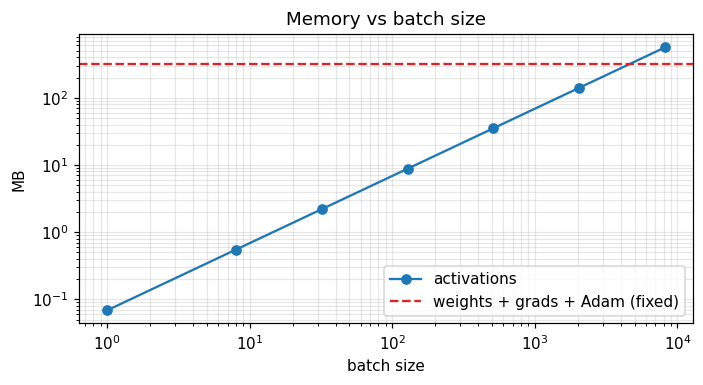

In [4]:
batches = np.array([1, 8, 32, 128, 512, 2048, 8192])
act = np.array([training_memory(sizes, bs)["activations"] for bs in batches]) / 1e6
fixed = sum(v for k, v in training_memory(sizes, 1).items() if k != "activations") / 1e6

plt.figure(figsize=(6.5, 3.6))
plt.loglog(batches, act, "o-", label="activations")
plt.axhline(fixed, color="tab:red", ls="--", label="weights + grads + Adam (fixed)")
plt.xlabel("batch size"); plt.ylabel("MB"); plt.title("Memory vs batch size")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

## 3. Scaling up: will an LLM-sized model fit?
Parameters + gradients + Adam states cost **16 bytes/param** in fp32 (mixed precision also lands at 16: 2+2 fp16 weights/grads + 4+4+4 fp32 master/m/v). This ignores activations.

In [5]:
for name, P in [("1B", 1e9), ("7B", 7e9), ("70B", 70e9)]:
    print(f"{name:>4} params -> {16 * P / 1e9:7.0f} GB for weights+grads+Adam   (one 80 GB GPU holds 80)")

  1B params ->      16 GB for weights+grads+Adam   (one 80 GB GPU holds 80)
  7B params ->     112 GB for weights+grads+Adam   (one 80 GB GPU holds 80)
 70B params ->    1120 GB for weights+grads+Adam   (one 80 GB GPU holds 80)


### Sharding the states across $K$ GPUs (ZeRO idea)
| strategy | weights | grads | Adam states |
|---|---|---|---|
| plain data parallel (DDP) | full | full | full |
| ZeRO-1 | full | full | **1/K** |
| ZeRO-2 | full | **1/K** | **1/K** |
| ZeRO-3 / FSDP | **1/K** | **1/K** | **1/K** |

DDP       112.0 GB per GPU
ZeRO-1     63.0 GB per GPU
ZeRO-2     38.5 GB per GPU
ZeRO-3     14.0 GB per GPU


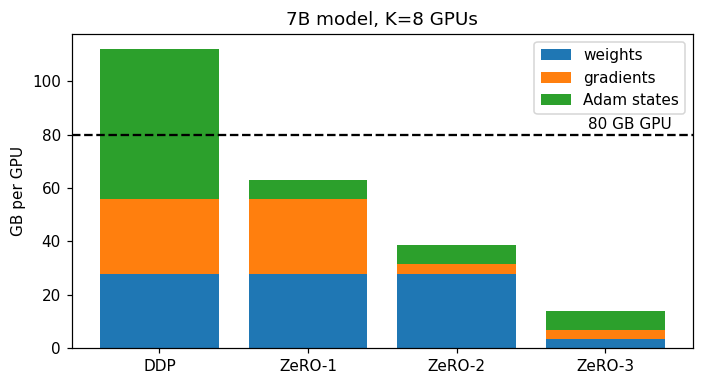

In [6]:
def per_gpu_gb(P, K, strategy):
    w, g, o = 4 * P, 4 * P, 8 * P
    if strategy == "DDP":    pass
    if strategy == "ZeRO-1": o /= K
    if strategy == "ZeRO-2": o /= K; g /= K
    if strategy == "ZeRO-3": o /= K; g /= K; w /= K
    return w / 1e9, g / 1e9, o / 1e9

P, K = 7e9, 8
strategies = ["DDP", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
parts = np.array([per_gpu_gb(P, K, s) for s in strategies])

fig, ax = plt.subplots(figsize=(6.5, 3.6))
bottom = np.zeros(len(strategies))
for j, lab in enumerate(["weights", "gradients", "Adam states"]):
    ax.bar(strategies, parts[:, j], bottom=bottom, label=lab); bottom += parts[:, j]
ax.axhline(80, color="k", ls="--"); ax.text(3.45, 82, "80 GB GPU", ha="right")
ax.set_ylabel("GB per GPU"); ax.set_title(f"7B model, K={K} GPUs")
ax.legend(); plt.tight_layout(); plt.show()
for s, t in zip(strategies, parts.sum(axis=1)):
    print(f"{s:<8}{t:7.1f} GB per GPU")

## 4. Data parallelism, simulated
Every "GPU" holds a **full copy** of the model, processes a **different slice** of the batch, and the gradients are **averaged** (all-reduce). Result: identical to one big batch.

In [7]:
def init_params(sizes, rng):
    return [(rng.normal(0, np.sqrt(2 / i), (i, o)), np.zeros(o)) for i, o in zip(sizes[:-1], sizes[1:])]

def grads_for(params, X, Y):
    """mean-loss gradients of a ReLU/softmax MLP on (X, Y)."""
    A, cache, L = X, [(None, X)], len(params)
    for l, (W, b) in enumerate(params, 1):
        Z = A @ W + b
        A = softmax(Z) if l == L else np.maximum(0, Z)
        cache.append((Z, A))
    delta, out = (A - Y) / len(X), [None] * L
    for l in range(L, 0, -1):
        out[l - 1] = (cache[l - 1][1].T @ delta, delta.sum(0))
        if l > 1:
            delta = (delta @ params[l - 1][0].T) * (cache[l - 1][0] > 0)
    return out

flat = lambda g: np.concatenate([np.concatenate([dW.ravel(), db]) for dW, db in g])

sizes = [20, 32, 16, 4]
params = init_params(sizes, rng)
N, K = 64, 4
X = rng.normal(size=(N, 20)); Y = np.eye(4)[rng.integers(0, 4, N)]

g_full = flat(grads_for(params, X, Y))                       # single device, whole batch

shards = np.array_split(np.arange(N), K)                      # each "GPU" gets N/K samples
g_local = [flat(grads_for(params, X[s], Y[s])) for s in shards]
g_avg = sum(len(s) / N * g for s, g in zip(shards, g_local))  # all-reduce (weighted mean)

print("max |single - data-parallel| =", np.abs(g_full - g_avg).max())
assert np.allclose(g_full, g_avg)

max |single - data-parallel| = 5.551115123125783e-17


### Ring all-reduce: how the averaging is really done
Each GPU sends/receives only $\frac{2(K-1)}{K}$ of the gradient size – nearly independent of $K$.

In [8]:
def ring_allreduce(vectors):
    K = len(vectors)
    ch = [np.array_split(v.copy(), K) for v in vectors]       # ch[worker][chunk]
    for step in range(K - 1):                                  # phase 1: reduce-scatter
        for w in range(K):
            c, dst = (w - step) % K, (w + 1) % K
            ch[dst][c] = ch[dst][c] + ch[w][c]
    for step in range(K - 1):                                  # phase 2: all-gather
        for w in range(K):
            c, dst = (w + 1 - step) % K, (w + 1) % K
            ch[dst][c] = ch[w][c].copy()
    return [np.concatenate(c) for c in ch]

vecs = [rng.normal(size=1003) for _ in range(K)]
out = ring_allreduce(vecs)
assert all(np.allclose(o, sum(vecs)) for o in out)
size = vecs[0].nbytes
print(f"ring all-reduce correct on {K} workers")
print(f"bytes sent per worker = {2 * (K - 1) / K * size:,.0f}  (gradient size = {size:,} bytes)")

ring all-reduce correct on 4 workers
bytes sent per worker = 12,036  (gradient size = 8,024 bytes)


## 5. Model (pipeline) parallelism: split by layers instead
When a model does not fit on one GPU, assign consecutive layers to different GPUs and pass activations between them.

In [9]:
sizes = [1024, 8192, 8192, 8192, 8192, 1000]
n_dev = 2
layers = list(zip(sizes[:-1], sizes[1:]))
split = np.array_split(np.arange(len(layers)), n_dev)
micro_batch = 64
for d, idx in enumerate(split):
    P = sum(layers[i][0] * layers[i][1] + layers[i][1] for i in idx)
    print(f"GPU {d}: layers {[int(i) for i in idx]} -> {P/1e6:7.1f} M params, {16*P/1e9:5.2f} GB (fp32+Adam)")
    out_width = layers[idx[-1]][1]
    if d < n_dev - 1:
        print(f"      sends activations {micro_batch}x{out_width} = {micro_batch*out_width*4/1e6:.2f} MB to GPU {d+1} per micro-batch")

GPU 0: layers [0, 1, 2] ->   142.6 M params,  2.28 GB (fp32+Adam)
      sends activations 64x8192 = 2.10 MB to GPU 1 per micro-batch
GPU 1: layers [3, 4] ->    75.3 M params,  1.20 GB (fp32+Adam)


### Summary
| technique | splits | communicates | solves |
|---|---|---|---|
| data parallel | the batch | gradients (all-reduce) | throughput |
| ZeRO / FSDP | optimizer, grads, weights | shards on demand | per-GPU memory |
| pipeline parallel | layers | activations | model too big for one GPU |
| tensor parallel | each matmul | partial results | huge layers |

### Try it yourself
1. Add gradient checkpointing to the estimator: store only every $\sqrt{L}$-th layer's activations. How much does the activation memory shrink?
2. Extend `per_gpu_gb` with fp16/bf16 mixed precision (2-byte weights & grads, 4-byte master weights and Adam states).
3. Simulate *gradient accumulation*: 4 micro-batches of 16 vs one batch of 64 – prove the gradients are identical.